Ejercicio 1

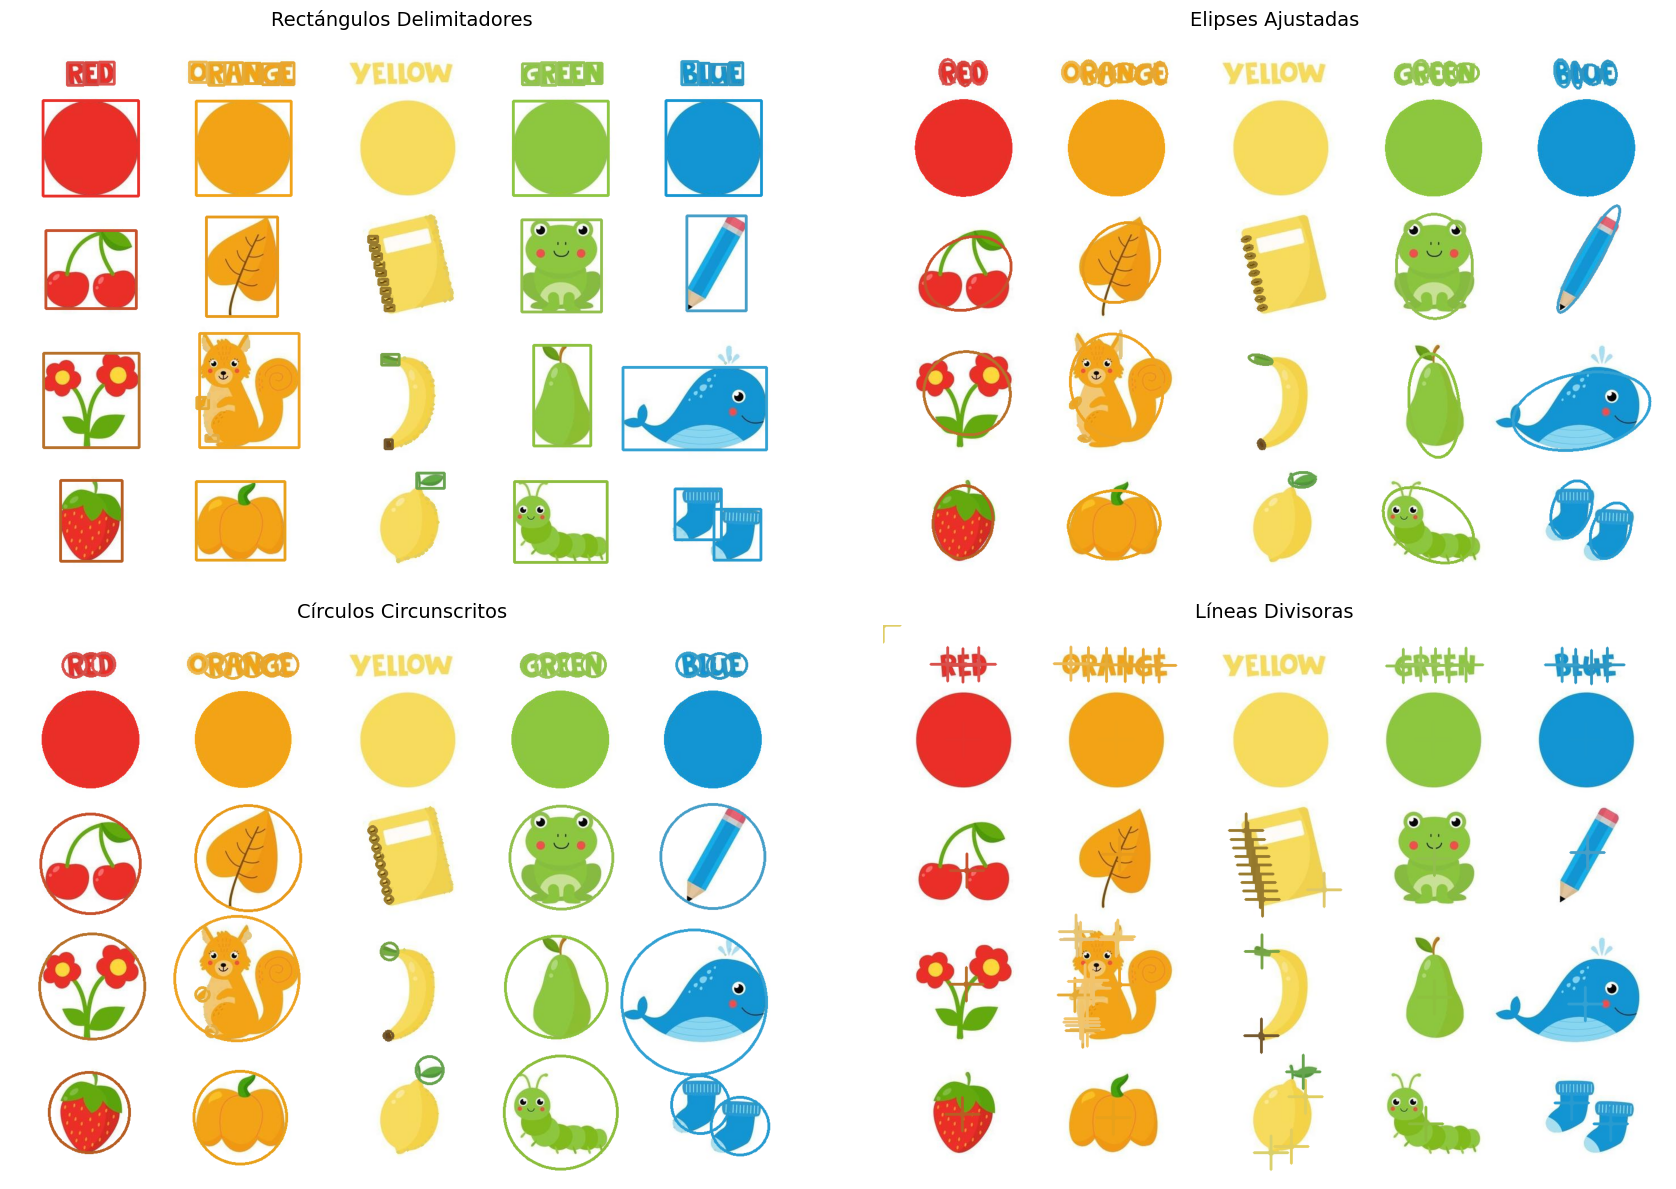

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

ruta = r"D:\Franz Caballero\Procesamiento de imagenes\Actividades\Ejercicios python\unidad2\ultimoLAB\colores.jpg"
imagen = cv2.imread(ruta)
original = imagen.copy()
gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)

ret, bin = cv2.threshold(gray, 200, 255, cv2.THRESH_BINARY_INV)

contornos, jerarquia = cv2.findContours(bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)



img_rect = original.copy()
img_elipse = original.copy()
img_circulo = original.copy()
img_lineas = original.copy()

pixeles_por_cm = None 

for i, cnt in enumerate(contornos):
    M = cv2.moments(cnt)
    
    if M['m00'] != 0:
        cx = int(M["m10"] / M["m00"])
        cy = int(M["m01"] / M["m00"])
    else:
        cx, cy = 0, 0



    mascara = np.zeros(gray.shape, np.uint8)
    cv2.drawContours(mascara, [cnt], 0, 255, -1)
    color_promedio = cv2.mean(original, mask=mascara)[:3]
    color_rgb = (int(color_promedio[2]), int(color_promedio[1]), int(color_promedio[0]))
    color_bgr = (int(color_promedio[0]), int(color_promedio[1]), int(color_promedio[2]))



    x, y, w, h = cv2.boundingRect(cnt)
    
    if i == 0:
        ancho_real_cm = 6  
        pixeles_por_cm = w / ancho_real_cm


    cv2.rectangle(img_rect, (x, y), (x + w, y + h), color_bgr, 3)
    
    
    
    if len(cnt) >= 5: 
        elipse = cv2.fitEllipse(cnt)
        cv2.ellipse(img_elipse, elipse, color_bgr, 3)
    
    
    
    (x_c, y_c), radio = cv2.minEnclosingCircle(cnt)
    centro_circulo = (int(x_c), int(y_c))
    radio = int(radio)
    cv2.circle(img_circulo, centro_circulo, radio, color_bgr, 3)
    
    
    
    longitud = 30  
    cv2.line(img_lineas, (cx - longitud, cy), (cx + longitud, cy), color_bgr, 3)

    cv2.line(img_lineas, (cx, cy - longitud), (cx, cy + longitud), color_bgr, 3)

    cv2.circle(img_lineas, (cx, cy), 5, color_bgr, -1)

img_rect_rgb = cv2.cvtColor(img_rect, cv2.COLOR_BGR2RGB)
img_elipse_rgb = cv2.cvtColor(img_elipse, cv2.COLOR_BGR2RGB)
img_circulo_rgb = cv2.cvtColor(img_circulo, cv2.COLOR_BGR2RGB)
img_lineas_rgb = cv2.cvtColor(img_lineas, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(18, 12))

plt.subplot(2, 2, 1)
plt.imshow(img_rect_rgb)
plt.axis('off')
plt.title("Rectángulos Delimitadores", fontsize=14)

plt.subplot(2, 2, 2)
plt.imshow(img_elipse_rgb)
plt.axis('off')
plt.title("Elipses Ajustadas", fontsize=14)

plt.subplot(2, 2, 3)
plt.imshow(img_circulo_rgb)
plt.axis('off')
plt.title("Círculos Circunscritos", fontsize=14)

plt.subplot(2, 2, 4)
plt.imshow(img_lineas_rgb)
plt.axis('off')
plt.title("Líneas Divisoras", fontsize=14)

plt.tight_layout()
plt.show()

 Captura una imagen de tu rostro con tu dispositivo móvil y aplica:

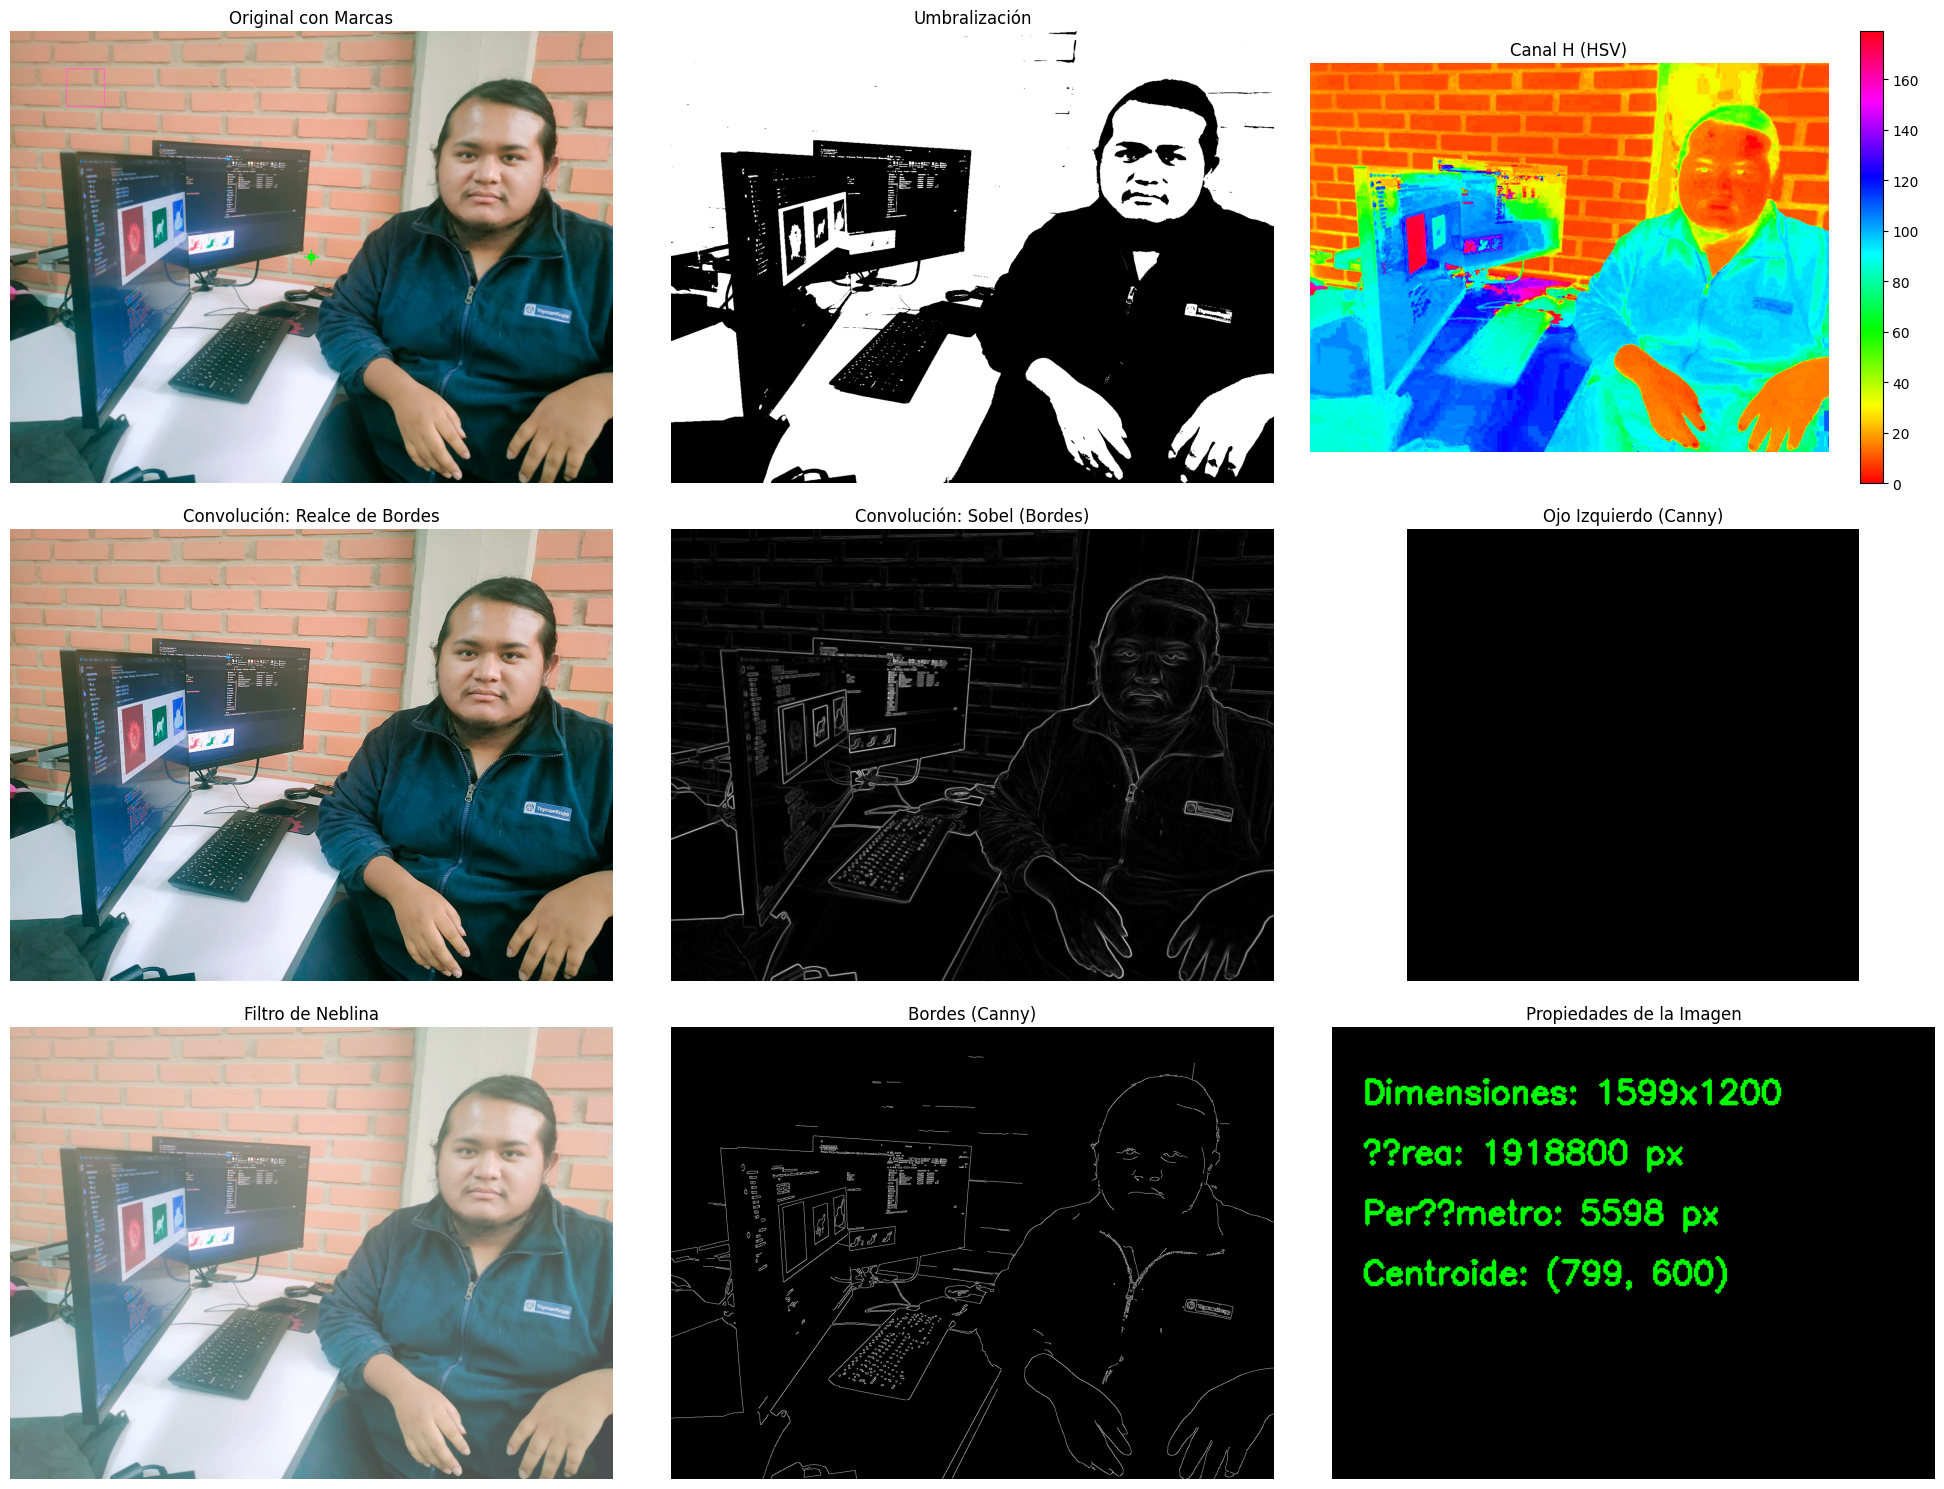

"# Guardar resultados si es necesario\ncv2.imwrite('rostro_marcado.jpg', face_marked)\ncv2.imwrite('umbralizacion.jpg', thresh)\ncv2.imwrite('canny_ojos.jpg', canny_eye)"

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

face = cv2.imread(r'D:\Franz Caballero\Procesamiento de imagenes\Actividades\Ejercicios python\imagenes\Foto Persona\originales\frente.jpg')
if face is None:
    raise FileNotFoundError("No se pudo cargar la imagen. Verifica la ruta.")

face_rgb = cv2.cvtColor(face, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(face, cv2.COLOR_BGR2GRAY)
_, thresh = cv2.threshold(gray, 127, 255, cv2.THRESH_BINARY)

hsv_face = cv2.cvtColor(face, cv2.COLOR_BGR2HSV)
hue_channel = hsv_face[:, :, 0]

kernel_propio = np.array([[0, -1, 0], 
                          [-1, 5, -1], 
                          [0, -1, 0]])
conv_propia = cv2.filter2D(face, -1, kernel_propio)
conv_propia_rgb = cv2.cvtColor(conv_propia, cv2.COLOR_BGR2RGB)

sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=5)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=5)
sobel_combined = np.sqrt(sobelx**2 + sobely**2)
sobel_combined = np.uint8(255 * sobel_combined / np.max(sobel_combined))

ojo_x, ojo_y, ojo_w, ojo_h = 150, 100, 100, 100
eye_roi = face[ojo_y:ojo_y+ojo_h, ojo_x:ojo_x+ojo_w]
canny_eye = cv2.Canny(eye_roi, 100, 200)

fog = cv2.addWeighted(face, 0.7, np.full_like(face, 255), 0.3, 0)
fog_rgb = cv2.cvtColor(fog, cv2.COLOR_BGR2RGB)

edges = cv2.Canny(gray, 100, 200)

height, width = face.shape[:2]
area_total = height * width
perimetro_total = 2 * (height + width)
centroide = (width//2, height//2)

face_marked = face.copy()
cv2.rectangle(face_marked, (ojo_x, ojo_y), 
             (ojo_x+ojo_w, ojo_y+ojo_h), 
             (180, 105, 255), 2)
cv2.circle(face_marked, centroide, 10, (0, 255, 0), -1)
cv2.line(face_marked, (centroide[0]-20, centroide[1]), 
        (centroide[0]+20, centroide[1]), (0, 255, 0), 2)
cv2.line(face_marked, (centroide[0], centroide[1]-20), 
        (centroide[0], centroide[1]+20), (0, 255, 0), 2)
face_marked_rgb = cv2.cvtColor(face_marked, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(20, 15))

plt.subplot(3, 3, 1)
plt.imshow(face_marked_rgb)
plt.title('Original')
plt.axis('off')

plt.subplot(3, 3, 2)
plt.imshow(thresh, cmap='gray')
plt.title('Umbralización')
plt.axis('off')

plt.subplot(3, 3, 3)
plt.imshow(hue_channel, cmap='hsv')
plt.title('HSV')
plt.axis('off')
plt.colorbar()

plt.subplot(3, 3, 4)
plt.imshow(conv_propia_rgb)
plt.title('Convolucion')
plt.axis('off')

plt.subplot(3, 3, 5)
plt.imshow(sobel_combined, cmap='gray')
plt.title('Convolucion: Sobel')
plt.axis('off')

plt.subplot(3, 3, 6)
plt.imshow(canny_eye, cmap='gray')
plt.title('Ojo Izquierdo (Canny)')
plt.axis('off')

plt.subplot(3, 3, 7)
plt.imshow(fog_rgb)
plt.title('Filtro de Neblina')
plt.axis('off')

plt.subplot(3, 3, 8)
plt.imshow(edges, cmap='gray')
plt.title('Bordes (Canny)')
plt.axis('off')

plt.subplot(3, 3, 9)
text_img = np.zeros((300, 400, 3), dtype=np.uint8)
props = f"Dimensiones: {width}x{height}\nÁrea: {area_total} px\nPerímetro: {perimetro_total} px\nCentroide: {centroide}"
y = 50
for line in props.split('\n'):
    cv2.putText(text_img, line, (20, y), 
               cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 255, 0), 2)
    y += 40
plt.imshow(text_img)
plt.title('Propiedades de la Imagen')
plt.axis('off')

plt.tight_layout()
plt.show()

Script para identificar objetos

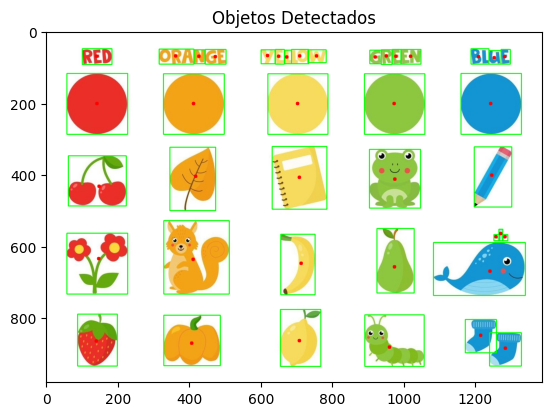

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
def detect_objects(image_path):
    img = cv2.imread(image_path)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, thresh = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY_INV)
    
    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    for cnt in contours:
        if cv2.contourArea(cnt) > 100: 
            x, y, w, h = cv2.boundingRect(cnt)
            cv2.rectangle(img, (x, y), (x+w, y+h), (0, 255, 0), 2)
            
            M = cv2.moments(cnt)
            cx = int(M['m10']/M['m00'])
            cy = int(M['m01']/M['m00'])
            cv2.circle(img, (cx, cy), 5, (0, 0, 255), -1)
    plt.title('Objetos Detectados')
    plt.imshow(cv2.cvtColor(img,cv2.COLOR_BGR2RGB))

detect_objects(r'D:\Franz Caballero\Procesamiento de imagenes\Actividades\Ejercicios python\unidad2\ultimoLAB\colores.jpg')